In [1]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# RISE Data Science Practicum
## Week 2, Day 2 — Linear Algebra: Seeing Data as Geometry

**Goal for today:** build an intuition for the mathematical structures that underpin
almost every machine learning model — vectors, matrices, and the operations that
transform them. We'll use NumPy throughout, and tie every idea back to the
weather-station data you already know.

### Roadmap
1. **Vectors and Data Points** — one row of data as a point in space
2. **Matrices and Datasets** — the full table as a matrix
3. **Shape, Size, and Rank** — what the dimensions of a matrix actually mean
4. **Key Operations** — dot product and matrix multiplication
5. **Visual Math Ideas** — the identity matrix and rotation

---

## Setup — imports and data

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load the weather dataset — same file used in Days 3 & 4
df = pd.read_csv("station_weather.csv")

# Pull out one day of RISE-01 for row-level examples
rise01 = df[(df["station_id"] == "RISE-01") & (df["date"] == "2026-06-15")].copy()
rise01 = rise01[["hour", "temperature_f", "humidity_pct", "wind_mph"]].reset_index(drop=True)
print(rise01)
get_first_row = df.iloc[0]
print(get_first_row)

   hour  temperature_f  humidity_pct  wind_mph
0     6           59.7          87.3       6.7
1     8           60.2          93.8       9.1
2    10           65.0          79.9       6.3
3    12           71.6          64.1       7.3
4    14           70.6          61.0       4.8
5    16           67.6           NaN       4.0
6    18           64.5          79.1       8.6
7    20           62.2          80.6       2.6
date             2026-06-15
station_id          RISE-01
hour                      6
temperature_f          59.7
humidity_pct           87.3
wind_mph                6.7
Name: 0, dtype: object


---

## 1. Vectors and Data Points

### What is a vector?

A **vector** is an ordered list of numbers. In data science, one row of a dataset
is a vector — each number is one *feature* (a measured quantity).

```
observation = [temperature, humidity, wind_speed]
            = [71.6,        64.1,     7.3        ]
```

Geometrically, that triple of numbers is a **point in 3-dimensional space** —
or equivalently, an arrow from the origin to that point.

The number of features is the **dimension** of the vector. With 3 features,
each observation lives in 3-D space. With 100 features, it lives in 100-D space
(impossible to draw, but the math is identical).

### 1a. Creating and inspecting vectors

In [9]:
# One observation from our dataset as a NumPy vector
obs = np.array([71.6, 64.1, 7.3])   # [temp, humidity, wind]

print("Vector:", obs)
print("Shape :", obs.shape)    # (3,) means 3 elements, 1-D
print("Length:", len(obs))     # same as number of features

Vector: [71.6 64.1  7.3]
Shape : (3,)
Length: 3


### 1b. Vector arithmetic

Adding two vectors adds their components. Multiplying by a scalar scales all
components uniformly. These operations have clean geometric interpretations —
add = shift, scale = stretch.

In [10]:
morning = np.array([60.2, 93.8, 9.1])   # hour-8 reading
noon    = np.array([71.6, 64.1, 7.3])   # hour-12 reading

# Component-wise addition and subtraction
change = noon - morning
print("Change from morning to noon:", change)

# Scaling a vector (multiply every element by a constant)
doubled = 2 * morning
print("Doubled morning vector:", doubled)

Change from morning to noon: [ 11.4 -29.7  -1.8]
Doubled morning vector: [120.4 187.6  18.2]


### 1c. Visualising a 2-D vector

We can't easily draw a 100-D vector, but a 2-D version shows the key idea:
a vector is an **arrow** from the origin, pointing to a location in space.

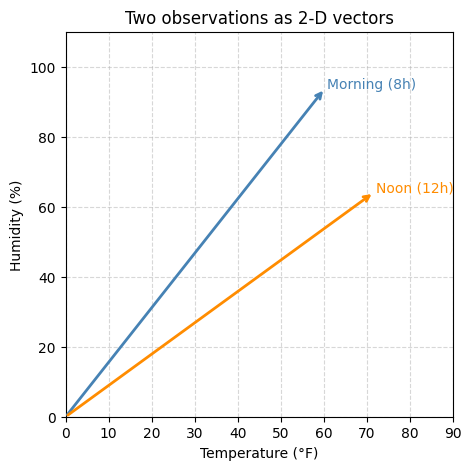

In [25]:
# Worked Example — plotting two observations as 2-D arrows
fig, ax = plt.subplots(figsize=(5, 5))

vectors = {
    "Morning (8h)":  np.array([60.2, 93.8]),   # [temp, humidity]
    "Noon (12h)":    np.array([71.6, 64.1]),
}
colors = ["steelblue", "darkorange"]

for (label, v), color in zip(vectors.items(), colors):
    ax.annotate("", xy=v, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.text(v[0]+0.5, v[1], label, color=color, fontsize=10)

ax.set_xlim(0, 90)
ax.set_ylim(0, 110)
ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Humidity (%)")
ax.set_title("Two observations as 2-D vectors")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()


> **Key idea:** Each data point is a location in feature space. The distance and
> angle between points tell us how similar (or different) they are.
> This geometric view is what drives clustering, PCA, and many other algorithms.

### Try It
Create two 2-D vectors from any two rows in `rise01` using the columns
`temperature_f` and `humidity_pct`. Print both vectors and their difference.
What does the difference vector tell you physically?

In [26]:
# Your code here


---

## 2. Matrices and Datasets

### What is a matrix?

A **matrix** is a 2-D grid of numbers — rows and columns. Your entire dataset
is a matrix: each **row** is one observation (one vector), each **column** is one
feature.

```
       temp    humidity   wind
row 0 [ 59.7,   87.3,     6.7  ]
row 1 [ 60.2,   93.8,     9.1  ]
row 2 [ 65.0,   79.9,     6.3  ]
  ...
```

This is exactly what a pandas DataFrame stores — pandas is essentially a
user-friendly wrapper around a NumPy matrix.

In [12]:
# Convert the numeric columns of rise01 into a raw NumPy matrix
feature_cols = ["temperature_f", "humidity_pct", "wind_mph"]
X = rise01[feature_cols].to_numpy()

print("Matrix X:")
print(X)
print()
print("Type :", type(X))
print("Shape:", X.shape)   # (rows, columns) = (observations, features)

Matrix X:
[[59.7 87.3  6.7]
 [60.2 93.8  9.1]
 [65.  79.9  6.3]
 [71.6 64.1  7.3]
 [70.6 61.   4.8]
 [67.6  nan  4. ]
 [64.5 79.1  8.6]
 [62.2 80.6  2.6]]

Type : <class 'numpy.ndarray'>
Shape: (8, 3)


### Accessing rows and columns

Once you have a NumPy matrix, indexing follows the `[row, column]` convention
you saw in Day 3 with pandas `.iloc`.

In [13]:
print("First row (first observation):", X[0])
print("Third column (all wind values):", X[:, 2])
print("Element at row 2, column 1    :", X[2, 1])

First row (first observation): [59.7 87.3  6.7]
Third column (all wind values): [6.7 9.1 6.3 7.3 4.8 4.  8.6 2.6]
Element at row 2, column 1    : 79.9


### Try It
From the full `df`, create a NumPy matrix using columns
`temperature_f`, `humidity_pct`, `wind_mph` for **all three stations**.
Print its shape and the values in the **last row**.

In [29]:
# Your code here


---

## 3. Shape, Size, and Rank

| Term | What it means | NumPy attribute |
|------|--------------|-----------------|
| **Shape** | `(rows, columns)` — the dimensions of the matrix | `.shape` |
| **Size** | total number of elements = rows × columns | `.size` |
| **Rank** | how many *linearly independent* rows/columns the matrix has | `np.linalg.matrix_rank()` |

**Rank** is the more subtle one. Intuitively: if one column is just a multiple
of another column (e.g. temperature in °F and temperature in °C), those two
columns carry the *same* information — they don't add a new "direction" in
feature space. The rank counts how many genuinely independent directions exist.

A matrix with rank less than its number of columns is called **rank-deficient**,
and this causes problems for many machine-learning algorithms.

In [ ]:
feature_cols = ["temperature_f", "humidity_pct", "wind_mph"]
X = rise01[feature_cols].dropna().to_numpy()   # drop the one row with a missing value

print("Shape:", X.shape)
print("Size :", X.size)
print("Rank :", np.linalg.matrix_rank(X))
print()

# Demonstrate rank drop: add a column that is a linear combination of existing ones
# use rank to see if there are redundant rows in datasets
temp_copy = X[:, 0] * 5
X_redundant = np.column_stack([X, temp_copy])

print("Shape with redundant column:", X_redundant.shape)
print("Rank  with redundant column:", np.linalg.matrix_rank(X_redundant))
print("(rank did not increase — new column carries no new information)")


Shape: (7, 3)
Size : 21
Rank : 3

Shape with redundant column: (7, 4)
Rank  with redundant column: 3
(rank did not increase — new column carries no new information)


### Try It
Build a 3×3 matrix by hand:

```
A = [[1, 2, 3],
     [4, 5, 6],
     [5, 7, 9]]
```

What is its rank, and why is it not 3?
*(Hint: look at whether the third row is a sum of the first two.)*

In [35]:
# Your code here

# Answer: 


---

## 4. Key Operations

### 4a. Dot Product

The **dot product** of two vectors **a** and **b** is:

$$\mathbf{a} \cdot \mathbf{b} = a_1 b_1 + a_2 b_2 + \cdots + a_n b_n$$

It multiplies matching components and sums the results. The outcome is a
**single number** (a scalar).

**What it measures:** how much two vectors "line up" or point in the same direction.

- Large positive → strongly aligned (same direction)
- Near zero → roughly perpendicular (unrelated)
- Negative → pointing in opposite directions

This is the computation at the heart of every linear model, neural network layer,
and similarity search.

In [14]:
a = np.array([71.6, 64.1, 7.3])    # noon observation
b = np.array([70.6, 61.0, 4.8])    # 2-pm observation

# Method 1: manual (show what's happening)
manual = sum(ai * bi for ai, bi in zip(a, b))

# Method 2: NumPy (what you'll always use in practice)
dot = np.dot(a, b)

# Method 3: @ operator — clean and Pythonic
dot_at = a @ b

print(f"Manual   : {manual:.2f}")
print(f"np.dot() : {dot:.2f}")
print(f"@ operator: {dot_at:.2f}")
print("All three give the same result.")


Manual   : 9000.10
np.dot() : 9000.10
@ operator: 9000.10
All three give the same result.


### Cosine similarity — the normalised dot product: Cosine similarity is a metric used to measure how similar two vectors are

$$\text{Cosine Similarity} = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|} = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} \sqrt{\sum_{i=1}^{n} B_i^2}}$$

The raw dot product depends on how long the vectors are. To compare only
**direction** (not magnitude), divide by the product of the vector lengths.
The result is the **cosine of the angle** between them, always between -1 and 1.

In [40]:
# Worked Example — cosine similarity between morning and noon observations
morning = np.array([60.2, 93.8, 9.1])
noon    = np.array([71.6, 64.1, 7.3])

cosine_sim = np.dot(morning, noon) / (np.linalg.norm(morning) * np.linalg.norm(noon))

print(f"Dot product       : {np.dot(morning, noon):.2f}")
print(f"||morning||       : {np.linalg.norm(morning):.2f}") # l1_norm
print(f"||noon||          : {np.linalg.norm(noon):.2f}")  #l1_norm = np.linalg.norm(noon, ord=1) (Pass ord=1)
print(f"Cosine similarity : {cosine_sim:.4f}")
print(f"Angle (degrees)   : {np.degrees(np.arccos(cosine_sim)):.2f}°")
print()
print("Close to 1.0 → vectors point in similar directions → observations are similar")

Dot product       : 10389.33
||morning||       : 111.83
||noon||          : 96.38
Cosine similarity : 0.9640
Angle (degrees)   : 15.43°

Close to 1.0 → vectors point in similar directions → observations are similar


### Try It
Pick any two rows from `rise01` as vectors (using all three numeric features).
Compute their dot product and cosine similarity. Which pair of readings
(morning vs noon, noon vs evening, etc.) are most similar by this measure?

In [13]:
# Your code here


---

### 4b. Matrix Multiplication

Matrix multiplication extends the dot product to whole tables. If **X** has shape
`(m, n)` and **W** has shape `(n, p)`, then **X @ W** has shape `(m, p)`.

Each element of the result is a dot product between one **row of X** and one
**column of W**.

**Why it matters in ML:** multiplying your data matrix **X** by a weight matrix **W**
is exactly what a linear layer in a neural network does — it transforms each
observation into a new set of values (the layer's outputs).

In [14]:
# Concrete example: scale each feature by a different weight
# X shape: (8 observations, 3 features)
X = rise01[["temperature_f", "humidity_pct", "wind_mph"]].to_numpy()

# Weight matrix: 3 features → 2 outputs
# Think of each column as a "recipe" for a new composite measurement
W = np.array([
    [0.5, -0.3],   # temperature weights
    [0.2,  0.6],   # humidity weights
    [0.1,  0.1],   # wind weights
])

# Matrix multiply: (8, 3) @ (3, 2) → (8, 2)
Z = X @ W

print("X shape:", X.shape)
print("W shape:", W.shape)
print("Z shape:", Z.shape)
print()
print("First few rows of Z (transformed data):")
print(Z[:3].round(2))

X shape: (8, 3)
W shape: (3, 2)
Z shape: (8, 2)

First few rows of Z (transformed data):
[[47.98 35.14]
 [49.77 39.13]
 [49.11 29.07]]


### Shape rule — the inner dimensions must match

```
(m, n)  @  (n, p)  →  (m, p)
         ↑↑
    these two must be equal
```

If they don't match, NumPy raises a `ValueError`. Always check `.shape`
before multiplying.

In [18]:
# Worked Example — what happens when shapes don't match
A = np.ones((3, 4))
B = np.ones((3, 2))   # inner dims: 4 ≠ 3 → will fail. Check B^T

try:
    C = A @ B
except ValueError as e:
    print("Error caught:", e)

# Transpose B so it becomes (2, 3)
B_T = B.T
print("A shape:", A.shape, "  B.T shape:", B_T.shape)
C = B_T@A
print("Result shape:", C.shape)

Error caught: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 4)
A shape: (3, 4)   B.T shape: (2, 3)
Result shape: (2, 4)


###  Try It
Create a weight matrix `W2` of shape `(3, 1)` — any values you like.
Multiply `X @ W2` to produce a single composite score for each of the 8
observations. Print the result and its shape.

In [19]:
# Your code here


---

## 5. Visual Math Ideas

### 5a. The Identity Matrix

The **identity matrix** **I** is the matrix equivalent of the number 1:
multiplying any matrix by it leaves the matrix unchanged.

```
I₃ = [[1, 0, 0],
      [0, 1, 0],
      [0, 0, 1]]
```

- Diagonal entries are 1, everything else is 0.
- **X @ I = X** always.
- It appears constantly in derivations of linear algebra (inverses, eigenvalues,
  regularisation in ML).

In [20]:
I = np.eye(3)    # 3×3 identity matrix
print("Identity matrix:")
print(I)
print()

X = rise01[["temperature_f", "humidity_pct", "wind_mph"]].dropna().to_numpy()
result = X @ I
print("X @ I equals X:", np.allclose(X, result))   # True

Identity matrix:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

X @ I equals X: True


### 5b. Rotation — matrices as transformations

Multiplying a vector by a **rotation matrix** spins it around the origin by a
chosen angle. This is a clean example of a matrix acting as a *transformation*
rather than just a container of data.

The 2-D rotation matrix for angle θ:

$$R(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$$

- Multiplying a 2-D point `[x, y]` by R(θ) gives the same point rotated θ degrees.
- The length of the vector doesn't change — only its direction.
- This is a "rigid" transformation: it preserves distances.

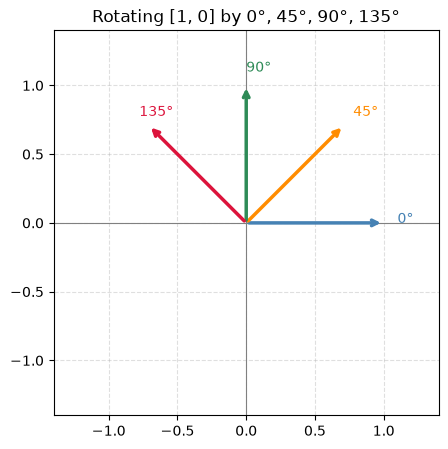

In [21]:
# Worked Example — rotate a set of 2-D points by several angles

def rotation_matrix(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

# Original point
p = np.array([1.0, 0.0])   # pointing right along the x-axis

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal")
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(0, color="gray", lw=0.8)
ax.grid(True, linestyle="--", alpha=0.4)
ax.set_title("Rotating [1, 0] by 0°, 45°, 90°, 135°")

angles = [0, 45, 90, 135]
colors = ["steelblue", "darkorange", "seagreen", "crimson"]

for angle, color in zip(angles, colors):
    R = rotation_matrix(angle)
    rotated = R @ p
    ax.annotate("", xy=rotated, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=color, lw=2.5))
    ax.text(rotated[0]*1.1, rotated[1]*1.1, f"{angle}°", color=color, fontsize=10)

plt.show()

### Try It
1. Define `R90 = rotation_matrix(90)`.
2. Apply it to the vector `[1, 0]`, then apply it again (rotate by another 90°).
3. What vector do you get after 4 rotations of 90°?
4. **Bonus:** verify that `np.linalg.det(R90)` equals 1.0 — this is a property of all rotation matrices.

In [19]:
def rotation_matrix(theta_deg):
    theta = np.radians(theta_deg)
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

# Your code here


---

## Capstone — End-to-End Linear Algebra Pipeline

Bring together everything from today on the full dataset.

**Step 1.** Build matrix `X` from the full `df` using columns
`temperature_f`, `humidity_pct`, `wind_mph`. Print its shape and rank.

**Step 2.** Compute the **column means** using `X.mean(axis=0)` and subtract them
from X to produce a *mean-centred* matrix `X_c`. (Centring is almost always
done before PCA and many other algorithms.)

**Step 3.** Define a weight matrix `W` of shape `(3, 2)` — use any values that
interest you. Compute `Z = X_c @ W`. Print the shape of Z and the first 5 rows.

**Step 4.** Compute the dot product between the **first** and **last** rows of `Z`.
Then compute their cosine similarity. Are those two observations pointing in
similar or different directions in the transformed space?

In [20]:
# Step 1
feature_cols = ["temperature_f", "humidity_pct", "wind_mph"]
X = df[feature_cols].dropna().to_numpy()   # drop the 2 rows with missing values
print("X shape:", X.shape)
print("X rank :", np.linalg.matrix_rank(X))

# Step 2
col_means = X.mean(axis=0)
X_c = X - col_means
print("Column means:", col_means.round(2))
print("X_c first row:", X_c[0].round(2))

# Step 3
W = np.array([[0.6, -0.4],
              [0.3,  0.5],
              [0.1,  0.2]])
Z = X_c @ W
print("Z shape:", Z.shape)
print("First 5 rows of Z:")
print(Z[:5].round(3))

# Step 4
first, last = Z[0], Z[-1]
dot = np.dot(first, last)
cosine = dot / (np.linalg.norm(first) * np.linalg.norm(last))
print(f"Dot product (first, last): {dot:.4f}")
print(f"Cosine similarity        : {cosine:.4f}")

X shape: (70, 3)
X rank : 3
Column means: [65.28 79.2   7.05]
X_c first row: [-5.58  8.1  -0.35]
Z shape: (70, 2)
First 5 rows of Z:
[[ -0.956   6.213]
 [  1.534   9.743]
 [ -0.036   0.313]
 [ -0.716 -10.027]
 [ -2.496 -11.677]]
Dot product (first, last): 43.8463
Cosine similarity        : 0.9876


---

## Wrap-Up

Today you covered:

- **Vectors** — one data row = one point in feature space; arithmetic is component-wise
- **Matrices** — the full dataset = a 2-D array; rows are observations, columns are features
- **Shape, Size, Rank** — dimensions tell you *how big*; rank tells you *how much information*
- **Dot product** — `np.dot(a, b)` or `a @ b` — measures alignment; cosine similarity normalises it
- **Matrix multiplication** — `X @ W` — transforms data from one space to another; the inner dimensions must match
- **Identity matrix** — `np.eye(n)` — the "do nothing" transformation
- **Rotation matrix** — a matrix that spins vectors without changing their length

**Quick reference:**
```python
v = np.array([...])                  # vector
M = np.array([[...], [...]])         # matrix

M.shape                              # (rows, cols)
M.size                               # rows * cols
np.linalg.matrix_rank(M)             # rank

np.dot(a, b)   /   a @ b            # dot product
X @ W                                # matrix multiply
np.eye(n)                            # n×n identity
np.linalg.norm(v)                    # vector length (L2 norm)
np.linalg.det(M)                     # determinant
```

**Up next:** these ideas plug directly into PCA, linear regression, and neural
network layers — the payoff for today's groundwork.